<a href="https://colab.research.google.com/github/neha-sharma4/ML-2_Lab/blob/main/ML_Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.DataFrame({
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
                "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temperature": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool",
                    "Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "Humidity": ["High","High","High","High","Normal","Normal","Normal",
                 "High","Normal","Normal","Normal","High","Normal","High"],
    "Wind": ["Weak","Strong","Weak","Weak","Weak","Strong","Strong",
             "Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "PlayTennis": ["No","No","Yes","Yes","Yes","No","Yes",
                   "No","Yes","Yes","Yes","Yes","Yes","No"]
})

display(df)

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


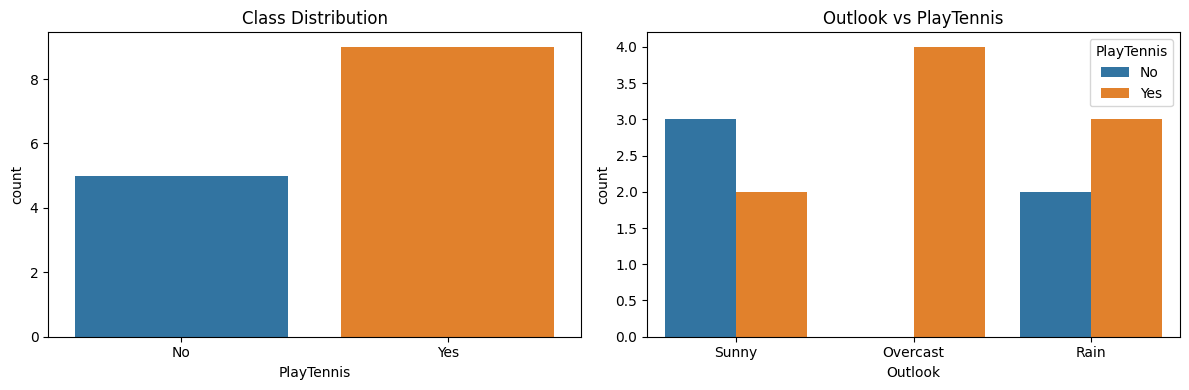

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="PlayTennis", hue="PlayTennis", ax=ax[0], legend=False)
ax[0].set_title("Class Distribution")

sns.countplot(data=df, x="Outlook", hue="PlayTennis", ax=ax[1])
ax[1].set_title("Outlook vs PlayTennis")

plt.tight_layout()
plt.show()

In [9]:
def foil_gain(p0, n0, p1, n1):
    if p1 == 0:
        return -np.inf

    return p1 * (
        math.log2(p1 / (p1 + n1)) -
        math.log2(p0 / (p0 + n0))
    )

In [10]:
features = ["Outlook", "Temperature", "Humidity", "Wind"]

def best_literal(data, used=[]):

    p0 = sum(data.PlayTennis == "Yes")
    n0 = sum(data.PlayTennis == "No")

    candidates = []

    for feature in features:
        if feature in used:
            continue

        for value in data[feature].unique():

            subset = data[data[feature] == value]

            p1 = sum(subset.PlayTennis == "Yes")
            n1 = sum(subset.PlayTennis == "No")

            gain = foil_gain(p0, n0, p1, n1)

            candidates.append(
                [feature, value, p1, n1, gain]
            )

    result = pd.DataFrame(
        candidates,
        columns=["Feature","Value","Positive","Negative","Gain"]
    )

    return result.sort_values(
        "Gain", ascending=False
    ).reset_index(drop=True)

In [11]:
def learn_rule(data):

    rule = []
    used = []
    current = data.copy()

    while sum(current.PlayTennis == "No") > 0:

        candidates = best_literal(current, used)

        best = candidates.iloc[0]

        feature = best.Feature
        value = best.Value

        rule.append((feature, value))
        used.append(feature)

        current = current[current[feature] == value]

        print(f"Selected: {feature} = {value}")
        print(f"FOIL Gain: {best.Gain:.4f}")

    return rule

,Feature,Value,Positive,Negative,Gain
0,Outlook,Overcast,4,0,2.549720
1,Humidity,Normal,6,1,2.490225
2,Wind,Weak,6,2,1.334355
3,Temperature,Cool,3,1,0.667177
4,Temperature,Mild,4,2,0.209870
5,Outlook,Rain,3,2,-0.298607
6,Temperature,Hot,2,2,-0.725140
7,Wind,Strong,3,3,-1.087710
8,Outlook,Sunny,2,3,-1.368996
9,Humidity,High,3,4,-1.754888


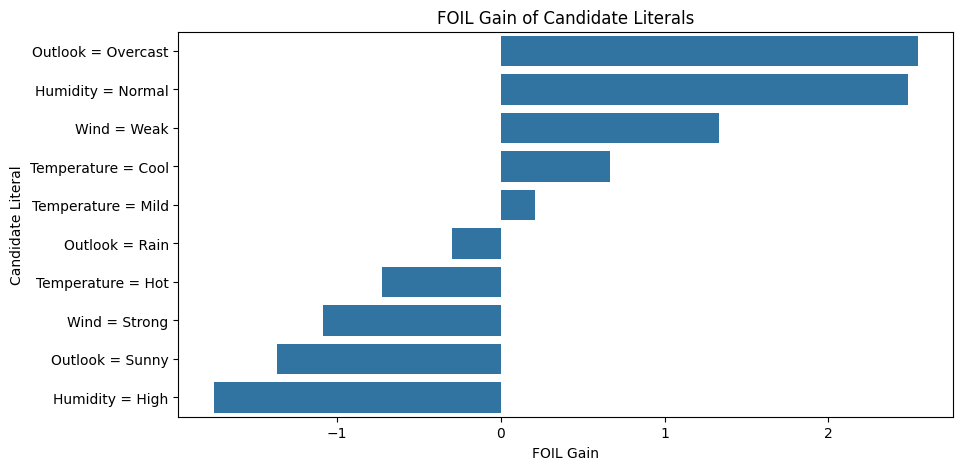

In [12]:
candidates = best_literal(df)

display(candidates)

plt.figure(figsize=(10, 5))

plot = candidates[candidates.Gain != -np.inf].copy()
plot["Literal"] = plot.Feature + " = " + plot.Value

sns.barplot(data=plot, x="Gain", y="Literal")

plt.title("FOIL Gain of Candidate Literals")
plt.xlabel("FOIL Gain")
plt.ylabel("Candidate Literal")
plt.show()

In [13]:
def foil(data):

    remaining = data.copy()
    rules = []

    while sum(remaining.PlayTennis == "Yes") > 0:

        print("\nLearning new rule...")
        rule = learn_rule(remaining)

        rules.append(rule)

        # Remove positive examples covered by rule
        mask = pd.Series(True, index=remaining.index)

        for feature, value in rule:
            mask &= remaining[feature] == value

        covered_positive = remaining[
            mask & (remaining.PlayTennis == "Yes")
        ]

        remaining = remaining.drop(covered_positive.index)

    return rules


rules = foil(df)

print("\nFINAL RULES")
for i, rule in enumerate(rules, 1):
    print(f"Rule {i}:", " AND ".join(
        f"{f}={v}" for f, v in rule
    ))


Learning new rule...
Selected: Outlook = Overcast
FOIL Gain: 2.5497

Learning new rule...
Selected: Humidity = Normal
FOIL Gain: 2.7123
Selected: Wind = Weak
FOIL Gain: 0.9658

Learning new rule...
Selected: Temperature = Mild
FOIL Gain: 1.6147
Selected: Humidity = Normal
FOIL Gain: 1.0000

Learning new rule...
Selected: Outlook = Rain
FOIL Gain: 1.0000
Selected: Wind = Weak
FOIL Gain: 1.5850

FINAL RULES
Rule 1: Outlook=Overcast
Rule 2: Humidity=Normal AND Wind=Weak
Rule 3: Temperature=Mild AND Humidity=Normal
Rule 4: Outlook=Rain AND Wind=Weak


In [14]:
def predict(row, rules):

    for rule in rules:

        if all(row[f] == v for f, v in rule):
            return "Yes"

    return "No"


df["Prediction"] = df.apply(
    lambda row: predict(row, rules),
    axis=1
)

display(df[["PlayTennis", "Prediction"]])

,PlayTennis,Prediction
0,No,No
1,No,No
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,No,No
6,Yes,Yes
7,No,No
8,Yes,Yes
9,Yes,Yes


Accuracy: 100.0 %


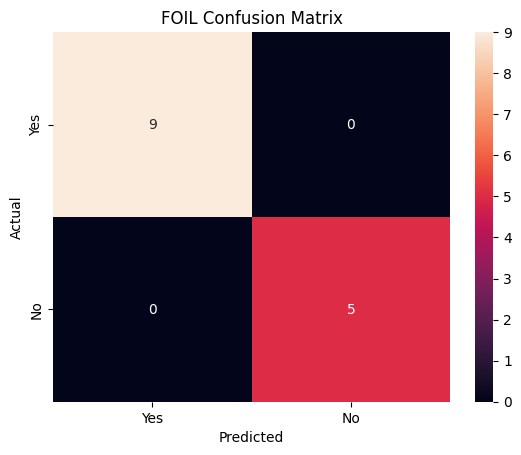

In [15]:
accuracy = accuracy_score(
    df.PlayTennis,
    df.Prediction
)

cm = confusion_matrix(
    df.PlayTennis,
    df.Prediction,
    labels=["Yes", "No"]
)

print("Accuracy:", round(accuracy * 100, 2), "%")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Yes", "No"],
    yticklabels=["Yes", "No"]
)

plt.title("FOIL Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
data = df[["Pclass", "Sex", "Embarked", "Survived"]].dropna()

# Convert everything to categorical/string
data["Pclass"] = data["Pclass"].astype(str)
data["Sex"] = data["Sex"].astype(str)
data["Embarked"] = data["Embarked"].astype(str)

# Convert target to Yes/No
data["Survived"] = data["Survived"].map({
    1: "Yes",
    0: "No"
})

print(data["Survived"].value_counts())
display(data.head())

Survived
No     549
Yes    340
Name: count, dtype: int64


,Pclass,Sex,Embarked,Survived
0,3,male,S,No
1,1,female,C,Yes
2,3,female,S,Yes
3,1,female,S,Yes
4,3,male,S,No


In [18]:
def foil_gain(p0, n0, p1, n1):
    if p1 == 0:
        return -np.inf

    return p1 * (
        math.log2(p1 / (p1 + n1)) -
        math.log2(p0 / (p0 + n0))
    )

In [19]:
def best_literal(data, used=None):

    if used is None:
        used = []

    candidates = []

    features = data.columns[:-1]

    p0 = sum(data["Survived"] == "Yes")
    n0 = sum(data["Survived"] == "No")

    for col in features:

        if col in used:
            continue

        for value in data[col].unique():

            new_data = data[data[col] == value]

            p1 = sum(new_data["Survived"] == "Yes")
            n1 = sum(new_data["Survived"] == "No")

            gain = foil_gain(p0, n0, p1, n1)

            candidates.append(
                (gain, col, value, p1, n1)
            )

    candidates.sort(reverse=True)

    return candidates

In [20]:
def learn_rule(data):

    rule = []
    current = data.copy()
    used = []

    while (current["Survived"] == "No").any():

        candidates = best_literal(current, used)

        if not candidates:
            break

        gain, col, value, p1, n1 = candidates[0]

        if gain == -np.inf:
            break

        rule.append((col, value))
        used.append(col)

        current = current[current[col] == value]

    return rule

In [21]:
def foil(data):

    remaining = data.copy()
    rules = []

    while (remaining["Survived"] == "Yes").any():

        rule = learn_rule(remaining)

        if not rule:
            break

        rules.append(rule)

        # Find examples covered by rule
        mask = pd.Series(True, index=remaining.index)

        for col, value in rule:
            mask &= remaining[col] == value

        # Remove covered positive examples
        remaining = remaining[
            ~((mask) & (remaining["Survived"] == "Yes"))
        ]

    return rules

In [22]:
#training
rules = foil(data)

print("Learned FOIL Rules:\n")

for i, rule in enumerate(rules, 1):

    conditions = " AND ".join(
        f"{col} = {value}"
        for col, value in rule
    )

    print(f"Rule {i}: IF {conditions} THEN Survived = Yes")

Learned FOIL Rules:

Rule 1: IF Sex = female AND Pclass = 1 AND Embarked = C THEN Survived = Yes
Rule 2: IF Sex = female AND Pclass = 2 AND Embarked = C THEN Survived = Yes
Rule 3: IF Sex = female AND Pclass = 2 AND Embarked = Q THEN Survived = Yes
Rule 4: IF Sex = female AND Pclass = 2 AND Embarked = S THEN Survived = Yes
Rule 5: IF Sex = female AND Pclass = 1 AND Embarked = S THEN Survived = Yes
Rule 6: IF Sex = female AND Embarked = Q AND Pclass = 1 THEN Survived = Yes
Rule 7: IF Sex = female AND Embarked = Q AND Pclass = 3 THEN Survived = Yes
Rule 8: IF Sex = female AND Embarked = C AND Pclass = 3 THEN Survived = Yes
Rule 9: IF Pclass = 1 AND Embarked = C AND Sex = male THEN Survived = Yes
Rule 10: IF Sex = female AND Embarked = S AND Pclass = 3 THEN Survived = Yes
Rule 11: IF Pclass = 1 AND Embarked = S AND Sex = male THEN Survived = Yes
Rule 12: IF Sex = male AND Pclass = 3 AND Embarked = C THEN Survived = Yes
Rule 13: IF Pclass = 2 AND Sex = male AND Embarked = C THEN Survived =

In [23]:
def predict(row, rules):

    for rule in rules:

        if all(row[col] == value for col, value in rule):
            return "Yes"

    return "No"

In [24]:
def predict(row, rules):

    for rule in rules:

        if all(row[col] == value for col, value in rule):
            return "Yes"

    return "No"

In [26]:
y_true = data["Survived"]

y_pred = data.apply(
    lambda row: predict(row, rules),
    axis=1
)

print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 0.3847019122609674


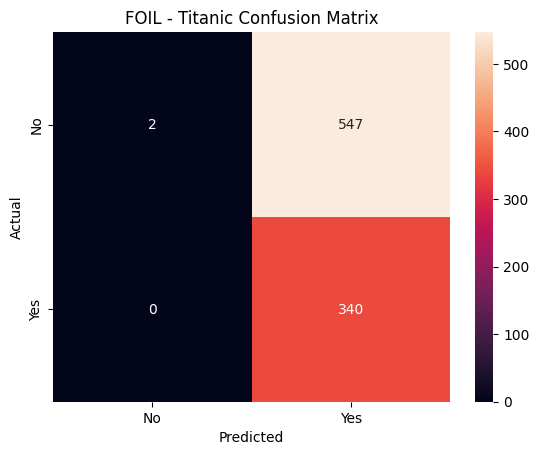

In [27]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=["No", "Yes"]
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("FOIL - Titanic Confusion Matrix")
plt.show()

In [28]:
candidates = best_literal(data)

gain_df = pd.DataFrame(
    candidates,
    columns=["Gain", "Feature", "Value", "Positive", "Negative"]
)

display(gain_df.head(10))

,Gain,Feature,Value,Positive,Negative
0,220.141959,Sex,female,231,81
1,95.310297,Pclass,1,134,80
2,49.614576,Embarked,C,93,75
3,26.624628,Pclass,2,87,97
4,0.802582,Embarked,Q,30,47
5,-39.649583,Embarked,S,217,427
6,-78.315421,Pclass,3,119,372
7,-110.917802,Sex,male,109,468


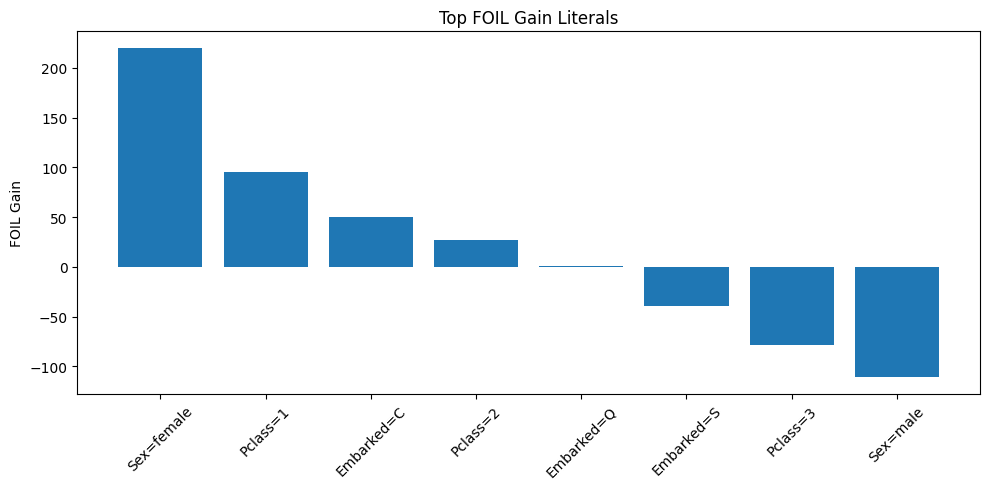

In [30]:
top = gain_df.head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top["Feature"] + "=" + top["Value"].astype(str),
    top["Gain"]
)

plt.xticks(rotation=45)
plt.ylabel("FOIL Gain")
plt.title("Top FOIL Gain Literals")
plt.tight_layout()
plt.show()

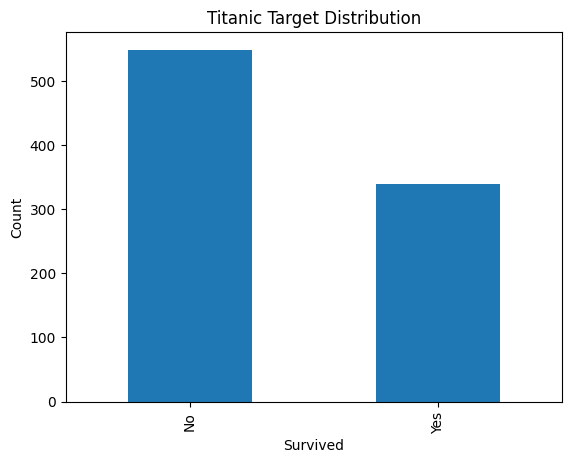

In [31]:
data["Survived"].value_counts().plot(
    kind="bar",
    title="Titanic Target Distribution"
)

plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

In [32]:
print("===== FOIL RESULTS =====")
print("Dataset size:", len(data))
print("Number of rules:", len(rules))
print("Accuracy:", accuracy_score(y_true, y_pred))

print("\nRules:")
for i, rule in enumerate(rules, 1):
    print(
        f"Rule {i}: " +
        " AND ".join(f"{c}={v}" for c, v in rule)
    )

===== FOIL RESULTS =====
Dataset size: 889
Number of rules: 16
Accuracy: 0.3847019122609674

Rules:
Rule 1: Sex=female AND Pclass=1 AND Embarked=C
Rule 2: Sex=female AND Pclass=2 AND Embarked=C
Rule 3: Sex=female AND Pclass=2 AND Embarked=Q
Rule 4: Sex=female AND Pclass=2 AND Embarked=S
Rule 5: Sex=female AND Pclass=1 AND Embarked=S
Rule 6: Sex=female AND Embarked=Q AND Pclass=1
Rule 7: Sex=female AND Embarked=Q AND Pclass=3
Rule 8: Sex=female AND Embarked=C AND Pclass=3
Rule 9: Pclass=1 AND Embarked=C AND Sex=male
Rule 10: Sex=female AND Embarked=S AND Pclass=3
Rule 11: Pclass=1 AND Embarked=S AND Sex=male
Rule 12: Sex=male AND Pclass=3 AND Embarked=C
Rule 13: Pclass=2 AND Sex=male AND Embarked=C
Rule 14: Embarked=S AND Sex=male AND Pclass=2
Rule 15: Pclass=3 AND Sex=male AND Embarked=S
Rule 16: Embarked=Q AND Sex=male AND Pclass=3
